# Information Retrieval in High Dimensional Data
## Assignment 1


## Curse of Dimensionality
### Task 1
Let $\mathbf{C}_d = \{\mathbf{x}\in \mathbb{R}^p\mid\|\mathbf{x}\|_\infty\leq\frac{d}{2}\}$ denote the $p$-dimensional hypercube of edge length $d$, centered at the orign.
#### *Part A*
Assume $\mathbf{X}$ to be uniformly distributed in $\mathbf{C}_1$. Determine $d$ in dependence of $p$ and $q\in[0, 1]$, such that
$$Pr(\mathbf{X}\in\mathbf{C}_d)=q$$
holds.

Fix $p \ge 0$. Since $X$ is uniformly distributed on $\mathcal{C}_1$, its probility density function is given by: $ f(x) =\begin{cases}
\dfrac{1}{\lambda^p(\mathcal{C}_1)} & \quad \text{for } x\in \mathcal{C}_1 \\
0 & \quad \text{otherwise} \end{cases}$, where $\lambda^p$ denotes the p-dimensional Lebesgue-measure.

Hence, $\lambda^p(\mathcal{C}_1)=\int\limits_{-\frac{1}{2}}^{\frac{1}{2}}\underbrace{\dots}_{\text{p times}}\int\limits_{-\frac{1}{2}}^{\frac{1}{2}}1dx_1\dots dx_p= 1$ and therefore: $ f(x) =\begin{cases}
1 & \quad \text{for } x\in \mathcal{C}_1 \\
0 & \quad \text{otherwise} \end{cases}$

Moreover it is $Pr(X \in \mathcal{C}_d)=\begin{cases} \dfrac{\lambda^p(\mathcal{C}_d)}{\lambda^p(\mathcal{C}_1)}\quad = \quad \lambda^p(\mathcal{C}_d)
& \quad \text{for } d <1 \\
1 & \quad \text{for } d\ge 1 \end{cases}$

So for $Pr(\mathbf{X}\in\mathcal{C}_d) = q$ follows for $q=1$ that $d\ge 1$

Assume now $q<1$. Then we have $Pr(\mathbf{X}\in\mathcal{C}_d)=\lambda^p(\mathcal{C}_d)=\int\limits_{-\frac{d}{2}}^{\frac{d}{2}}\underbrace{\dots}_{\text{p times}}\int\limits_{-\frac{d}{2}}^{\frac{d}{2}}1dx_1\dots dx_p= d^p$

Finally it follows for $q<1$ that $Pr(\mathbf{X}\in\mathcal{C}_d) = q \quad \Leftrightarrow \quad d=\sqrt[p]{q}$



#### *Part B*
Let the components of the $p$-dimensional random variable $\mathbf{X}^p$ be independent and have the standard normal distribution. It is known that $Pr(|\mathbf{X}^1|\leq2.576)=0.99$. For an arbitrary $p$, determine the probability $Pr(\|\mathbf{X}^p\|_\infty\gt2.576)$ for any of the components of $\mathbf{X}^p$ to lie outside of the interval $[-2.576, 2.576]$. Evaluate the value for $p = 2$, $p = 3$ and $p = 500$.

$$
\begin{align*}
& \because \quad \,\; Pr(|\mathbf{X}^1| \leq 2.576) = 0.99 &\\
& \Rightarrow \quad Pr(\|\mathbf{X}^p\| \leq 2.576) = (0.99)^p & (\because\text{ components of }\mathbf{X}^p \text{are independent})\\
& \Rightarrow \quad Pr(\|\mathbf{X}^p\|_\infty\gt2.576) = 1 - Pr(\|\mathbf{X}^p\| \leq 2.576) &\\
& \therefore \quad \,\; Pr(\|\mathbf{X}^p\|_\infty\gt2.576) = 1 - (0.99)^p &
\end{align*}
$$
Now, for $p = 2$, $p = 3$ and $p = 500$
$$
\begin{align*}
& Pr(\|\mathbf{X}^2\|_\infty\gt2.576) = 1 - (0.99)^2 \approx 0.0199 \\
& Pr(\|\mathbf{X}^3\|_\infty\gt2.576) = 1 - (0.99)^3 \approx 0.0297 \\
& Pr(\|\mathbf{X}^{500}\|_\infty\gt2.576) = 1 - (0.99)^{500} \approx 0.9934 \\
\end{align*}
$$
respectively.


### Task 2
Provide the PYTHON code to the following tasks (the code needs to be commented properly):
#### *Part A*
Sample $100$ uniformly distributed random vectors from the box $[-1, 1]^{d}$ for $d = 2$.

<function matplotlib.pyplot.show(close=None, block=None)>

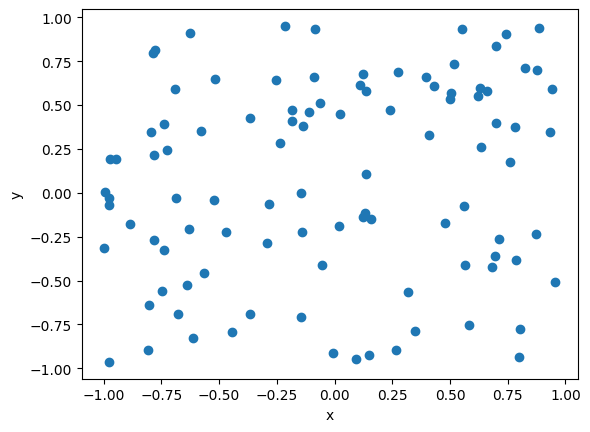

In [12]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

##  Sample 100 uniformly distributed random vectors from the box [−1, 1]d for d = 2.
def sample(n,d):
    X=np.random.uniform(-1,1,size=(n,d))
    return X
X=sample(100,2)
plt.scatter(X[:,0],X[:,1])
plt.xlabel('x')
plt.ylabel('y')
plt.show

#### *Part B*
For each of the $100$ vectors determine the minimum angle to all other vectors. Then compute the average of these minimum angles. Note that for two vectors $\mathbf{x}$, $\mathbf{y}$ the cosine of the angle between the two vectors is defined as

$$\cos{((\mathbf{x}, \mathbf{y}))} = \frac{\langle \mathbf{x}, \mathbf{y} \rangle}{\|\mathbf{x}\|\|\mathbf{y}\|}.$$


In [14]:
def min_angle(X):
    ##calculate cosine of the angle between two vectors
    scalardot_mat=np.dot(X,X.T)
    X_norm=np.linalg.norm(X,axis=1)
    ##generate matrix of ||X||*||y||
    width=len(X[:,0])
    X_norm_mat=np.zeros((width,width))
    for i in range(width):
        X_norm_mat[:,i]=np.dot(X_norm[i],X_norm)
    X_angle=np.divide(scalardot_mat,X_norm_mat)
    ##matrix of cosine of angle between two vector s
    np.fill_diagonal(X_angle,0)
    MinAngle_cos=np.amax(X_angle,axis=0)
    ##calculate angle
    MinAngle=np.arccos(MinAngle_cos)

    return MinAngle


In [15]:
MinAng=min_angle(X)
ang_mean=np.mean(MinAng)
print('the avrage of these minimum angles is {}'.format(ang_mean))

the avrage of these minimum angles is 0.03226191153660978


#### *Part C*
Repeat the above for dimensions $d = 1, ..., 1000$ and use the results to plot the average minimum angle against the dimension.

In [17]:
def compute_average_min_angle(n, d):
    """
    Compute the average minimum angle between sampled vectors in dimensions 1 to d.

    :param n: Number of sampled vectors in [-1, 1]^d
    :param d: Maximum dimension to sweep
    :returns: Array of average minimum angles for each dimension
    """
    # Pre-allocate array for storing average minimum angles
    ang_mean = np.zeros((d + 1, 1))

    # Iterate over each dimension from 1 to d
    for i in range(1, d + 1):
        X = sample(n, i)              # Generate n random vectors in dimension i
        MinAng = min_angle(X)          # Compute the minimum angle between each vector and others
        ang_mean[i, 0] = np.mean(MinAng)  # Calculate and store the mean of minimum angles

    return ang_mean

# Compute the average minimum angle for sample size 100 across 1 to 1000 dimensions
ang_mean = compute_average_min_angle(100, 1000)

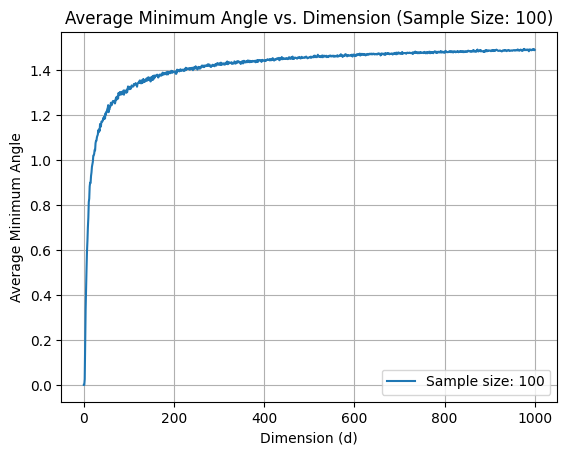

In [18]:
def plot_average_min_angle(n, d, ang_mean):
    """
    Plot the average minimum angle as a function of dimension.

    :param n: Number of sampled vectors
    :param d: Maximum dimension
    :param ang_mean: Array of average minimum angles
    """
    plt.plot(range(d + 1), ang_mean, label=f"Sample size: {n}")
    plt.xlabel("Dimension (d)")           # Label for the x-axis
    plt.ylabel("Average Minimum Angle")   # Label for the y-axis
    plt.title(f"Average Minimum Angle vs. Dimension (Sample Size: {n})")  # Title
    plt.legend()
    plt.grid(True)
    plt.show()

# Plot the results
plot_average_min_angle(100, 1000, ang_mean)

#### *Part D*
Give an interpretation of the result. What conclusion can you draw for $2$ randomly sampled vectors in a $d$-dimensional space?

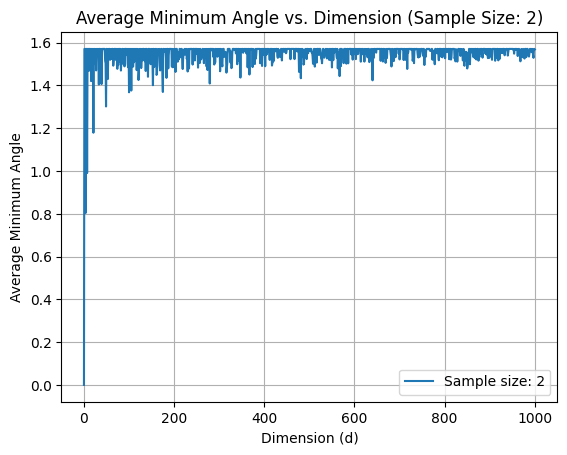

In [19]:
ang_mean=compute_average_min_angle(2,1000)
plot_average_min_angle(2,1000,ang_mean)

#### *Part E*
Does the result change if the sample size increases?

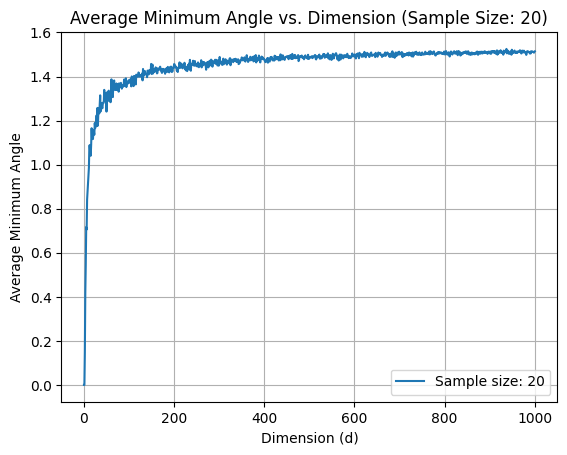

In [20]:
ang_mean=compute_average_min_angle(20,1000)
plot_average_min_angle(20,1000,ang_mean)


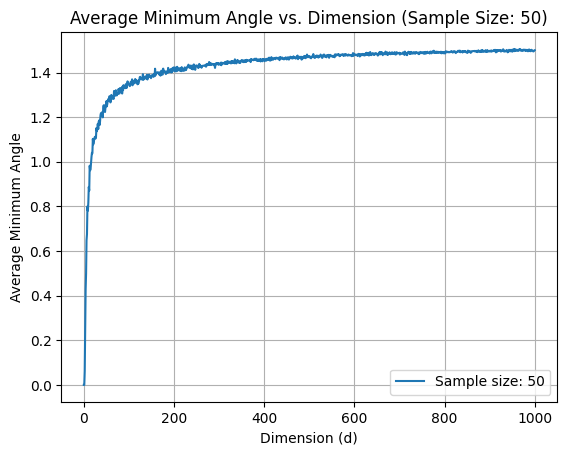

In [21]:
ang_mean=compute_average_min_angle(50,1000)
plot_average_min_angle(50,1000,ang_mean)


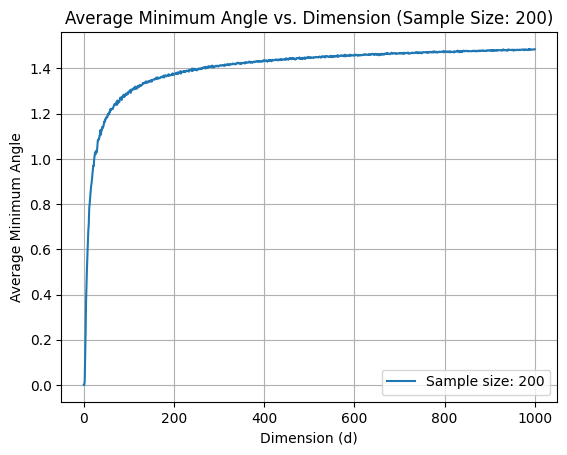

In [23]:
ang_mean=compute_average_min_angle(200,1000)
plot_average_min_angle(200,1000,ang_mean)

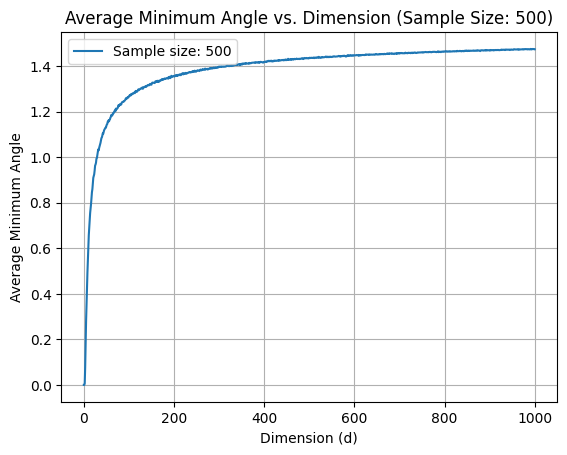

In [22]:
ang_mean=compute_average_min_angle(500,1000)
plot_average_min_angle(500,1000,ang_mean)

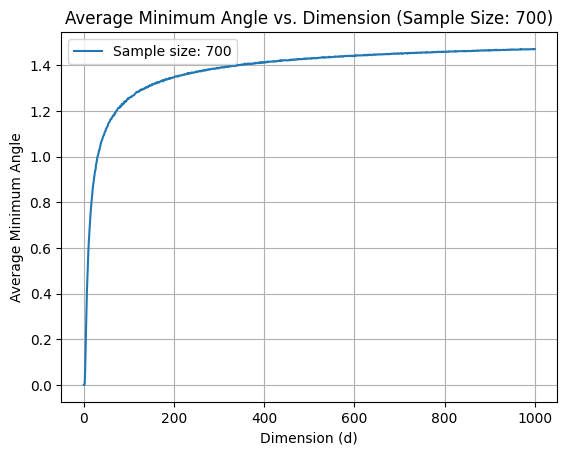

In [24]:
ang_mean=compute_average_min_angle(700,1000)
plot_average_min_angle(700,1000,ang_mean)

The Observations on Minimum Angles

- **Minimum Angle Approaches 90 Degrees**:  
  The minimum angle between a vector and its "neighbor" tends to converge to 90 degrees as the dimensionality increases. This highlights the phenomenon where vectors in high-dimensional spaces are almost orthogonal to each other.

- **Effect of Sample Size**:  
  As the sample size increases, the observed result remains consistent but becomes more stable. This indicates that increasing the number of sampled vectors reduces variability in the computed minimum angles, reinforcing the trend towards orthogonality.


## Statistical Decision Making
### Task 3
Answer the following questions. All answers must be justified.
#### *Part A*


The numbers in Figure 1 show the probability of the respective event to happen (e.g., the probability for the event $X = 1$ and $Y = 1$ is $0.02$). Is this table a probability table? If so, why?

    

part a answer:

Yes, the table is a probability table because the sum of all probabilities given in the table is 1 where:


$$
\sum_x \sum_y p_{X, Y}(x, y) = 0.4+0.14+0.05+0.02+0.26+0.13 = 1
$$

also, all probabilities in the table are non-negative.

### *Part B*

Based on Figure 1, give the conditional expectation $\mathbb{E}_{Y \mid X=2}[Y]$
 and the probability of the event $X = 1$ under the condition $Y = 3$.


part b answer:

1)*Conditional Expectation* :

When $X=2$, the conditional probabilities are calculated using:

$$p(Y = y \mid X = 2) = \frac{p(X = 2, Y = y)}{\sum_{y=1}^3 p(X = 2, Y = y)}$$


when $X = 2$, the joint probabilities are:

$$p(X = 2, Y = 1) = 0.4, \quad p(X = 2, Y = 2) = 0.14, \quad p(X = 2, Y = 3) = 0.05$$

The marginal probability of $X = 2$ is:

$$p(X = 2) = \sum_{y=1}^3 p(X = 2, Y = y) = 0.4 + 0.14 + 0.05 = 0.59$$

Therefore, the conditional probabilities are:

$$p(Y = 1 \mid X = 2) = \frac{0.4}{0.59}, \quad p(Y = 2 \mid X = 2) = \frac{0.14}{0.59}, \quad p(Y = 3 \mid X = 2) = \frac{0.05}{0.59}$$

The conditional expectation is:

$$\mathbb{E}_{Y \mid X=2}[Y] = \sum_{y=1}^3 y \cdot p(Y = y \mid X = 2)$$

$$\mathbb{E}_{Y \mid X=2}[Y] = 1 \cdot \frac{0.4}{0.59} + 2 \cdot \frac{0.14}{0.59} + 3 \cdot \frac{0.05}{0.59}$$

$$\mathbb{E}_{Y \mid X=2}[Y] = 1.406$$

-2)*probability of the event  $X=1$  under the condition  $Y=3$* :

Using the conditional probability formula:

$$p(X = 1 \mid Y = 3) = \frac{p(X = 1, Y = 3)}{\sum_{x=1}^2 p(X = x, Y = 3)}$$


From figure 1:

$$p(X = 1, Y = 3) = 0.13, \quad p(X = 2, Y = 3) = 0.05$$

The marginal probability for $Y = 3$ is:


$$p(Y = 3) = \sum_{x=1}^2 p(X = x, Y = 3) = 0.13 + 0.05 = 0.18$$


Thus:

$$p(X = 1 \mid Y = 3) = \frac{0.13}{0.18}$$



$$p(X = 1 \mid Y = 3) = 0.722$$





### *Part C*

Is the function $p(x, y)$ given by

$$p(x, y) =
\begin{cases}
1 & \text{for } 0 \leq x \leq 1, \, 0 \leq y \leq \frac{1}{2}, \\
0 & \text{otherwise,}
\end{cases}$$

a joint density function for two random variables?


part c answer:

A joint density function must satisfy the following condition :

$$ \int_{-\infty}^{\infty} \int_{-\infty}^{\infty} p(x,y) dx dy = 1  $$

Here we have:

$$ \int_{0}^{\frac{1}{2}} \int_{0}^{1} 1 dx dy=
\int_{0}^{1} \left[ \int_{0}^{\frac{1}{2}} 1 \, dy \right] dx = \int_{0}^{1} \left[ y \Big|_{0}^{\frac{1}{2}} \right] dx = \int_{0}^{1} \frac{1}{2} \, dx$$


$$\int_{0}^{1} \frac{1}{2} \, dx = \frac{1}{2} \cdot \left[ x \Big|_{0}^{1} \right] = \frac{1}{2} \cdot 1 = \frac{1}{2}$$

which doesn't fulfill the above condition. Therefore, $p(x,y)$ is NOT a joint probability distribution function.

### *Part D*

For two random variables $X$ and $Y$, the joint density function is given by

$$p(x, y) =
\begin{cases}
2e^{-(x+y)} & \text{for } 0 \leq x \leq y, \, 0 \leq y, \\
0 & \text{otherwise.}
\end{cases}$$

What are the marginal density functions for $X$ and $Y$ respectively?


part D answer:
$$ p(x)=\int_{x}^{\infty}p(x,y)dy $$

$$ p(x)=\int_{x}^{\infty}2e^{-(x+y)}dy $$

$$ p(x) = -2(e^{-(x+y)})\mid_x^\infty $$

$$ p(x) = -2(e^{-2x} + 0) $$

$$ p(x)=2e^{-2x} $$

$$ p(y)=\int_{0}^{y}p(x,y)dx $$

$$ p(y)=\int_{0}^{y}2e^{-(x+y)}dx $$

$$ p(y)= -2(e^{-(x+y)})\mid_0^y $$

$$ p(y)= -2(e^{-2y} - e^{-y}) $$

$$ p(y) = 2e^{-y} \big( 1 - e^{-y} \big) $$

### *Part E*

Let the joint density function of two random variables $X$ and $Y$ be given by

$$p(x, y) =
\begin{cases}
\frac{1}{15}(2x + 4y) & \text{for } 0 < x < 3, \, 0 < y < 1, \\
0 & \text{otherwise.}
\end{cases}$$

Determine the probability for $X \leq 2$ under the condition that $Y = \frac{1}{2}$.


part E answer:

$$ Pr(X\leq 2\mid Y=\frac{1}{2}) = \int_0^2 \frac{p(x, y)}{p(y)}dx$$

First we need to determine p(y)

$$ p(y) = \int_x p(x, y)\; \mathrm{d}x $$

$$ p(y) = \int_0^3 p(x, y)\; \mathrm{d}x $$

$$ p(y) = \int_0^3 \frac{1}{15}(2x+4y) \mathrm{d}x $$

$$ p(y) = \frac{1}{15}(x^2 + 4yx) \mid_0^3$$

$$ p(y) = \frac{1}{15}(9 + 12y - 0 - 0) $$

$$ p(y) = \frac{1}{5}\; (4y+3) $$

After substituting $y=\frac{1}{2}$

$$ p(y = 0.5) = \frac{1}{5}\; (4 \cdot 0.5 +3)= 1 $$
$$ Pr(X\leq 2\mid Y=\frac{1}{2}) = \int_0^2 \frac{p(x, y=0.5)}{p(y = 0.5)}dx$$

$$ Pr(X\leq 2\mid Y=\frac{1}{2}) = \int_0^2 \frac{1}{15}(2x+4\cdot0.5)\cdot\frac{1}{1}\; \mathrm{d}x $$

$$ Pr(X\leq 2\mid Y=\frac{1}{2}) = \frac{1}{15}\; (x^2+2x)\mid_0^2 $$

$$ Pr(X\leq 2\mid Y=\frac{1}{2}) = \frac{8}{15} $$